In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -l "/content/drive/MyDrive/CarDogDataset.zip"

Streaming output truncated to the last 5000 lines.
    22023  2025-09-23 18:52   train/dogs/dog.4420.jpg
    29765  2025-09-23 18:52   train/dogs/dog.4421.jpg
    22205  2025-09-23 18:52   train/dogs/dog.4422.jpg
    43337  2025-09-23 18:52   train/dogs/dog.4424.jpg
    40130  2025-09-23 18:52   train/dogs/dog.4425.jpg
    15849  2025-09-23 18:52   train/dogs/dog.4426.jpg
     3631  2025-09-23 18:52   train/dogs/dog.4427.jpg
    13506  2025-09-23 18:52   train/dogs/dog.4431.jpg
    20657  2025-09-23 18:52   train/dogs/dog.4433.jpg
    24656  2025-09-23 18:52   train/dogs/dog.4436.jpg
    28128  2025-09-23 18:52   train/dogs/dog.4438.jpg
    19387  2025-09-23 18:52   train/dogs/dog.4439.jpg
    15212  2025-09-23 18:52   train/dogs/dog.444.jpg
     8298  2025-09-23 18:52   train/dogs/dog.4440.jpg
    18771  2025-09-23 18:52   train/dogs/dog.4441.jpg
     8370  2025-09-23 18:52   train/dogs/dog.4442.jpg
    23748  2025-09-23 18:52   train/dogs/dog.4443.jpg
    20835  2025-09-23 18:52   tr

In [ ]:
!unzip -o "/content/drive/MyDrive/CarDogDataset.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

In [ ]:
!ls /content/

drive  sample_data  test  train


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,Dense,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image

In [ ]:
#Use generator provided by keras (divides entire datset into small bacthes for easy processing)

Train_obj=keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int', #cat=0,dog=1
    batch_size=32,
    image_size=(256,256)
)

Validation_obj=keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int', #cat=0,dog=1
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
class_names = Train_obj.class_names
print(class_names)

['cats', 'dogs']


In [ ]:
#Normalize
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label

Train_obj=Train_obj.map(process)
Validation_obj=Validation_obj.map(process)

In [ ]:
#Now create CNN model
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
history=model.fit(Train_obj,epochs=10,validation_data=Validation_obj)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - accuracy: 0.5616 - loss: 2.5288 - val_accuracy: 0.6094 - val_loss: 0.6877
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 91ms/step - accuracy: 0.6505 - loss: 0.6515 - val_accuracy: 0.7234 - val_loss: 0.5404
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7361 - loss: 0.5270 - val_accuracy: 0.7756 - val_loss: 0.4714
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7787 - loss: 0.4555 - val_accuracy: 0.7382 - val_loss: 0.4885
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.8062 - loss: 0.3981 - val_accuracy: 0.7844 - val_loss: 0.4667
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8340 - loss: 0.3471 - val_accuracy: 0.7814 - val_loss: 0.4681
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.8679 - loss: 0.2863 - val_accuracy: 0.8202 - val_loss: 0.4728
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8990 - loss: 0.2231 - 

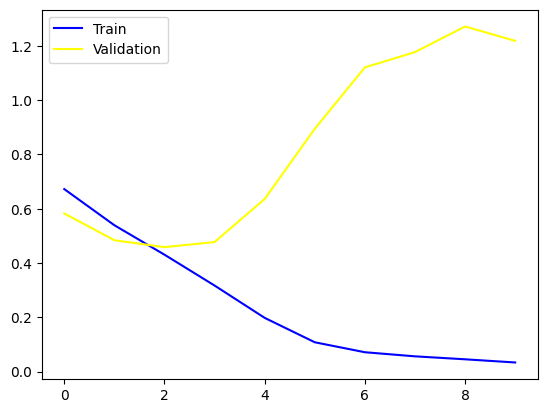

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='blue',label='Train')
plt.plot(history.history['val_loss'],color='yellow',label='Validation')
plt.legend()
plt.show()

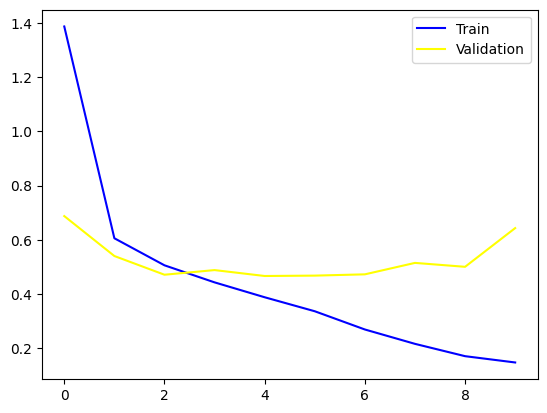

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='blue',label='Train')
plt.plot(history.history['val_loss'],color='yellow',label='Validation')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rabbit Imgg.jpg to rabbit Imgg.jpg


In [ ]:
!ls

Cat2.jpg  Cat_Image.jpg  Dog_Image.jpg	drive  sample_data  test  train


In [ ]:
#Load and Preprocess Image

# Path of uploaded image
img_path = '/content/Dog_Image.jpg'   # change to your file name

# Load image and resize
img = image.load_img(img_path, target_size=(256,256))

# Convert to array
img_array = image.img_to_array(img)

# Rescale
img_array = img_array / 255.0

# Expand dimensions (VERY IMPORTANT)
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)  # should be (1,150,150,3)

(1, 256, 256, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


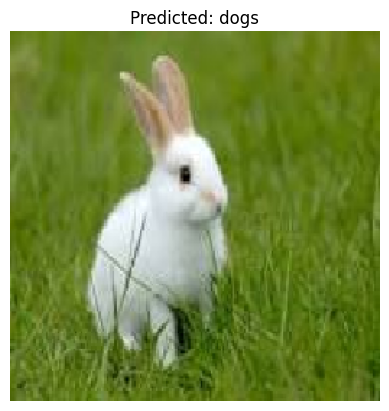

In [ ]:
#Prediction
prediction = model.predict(img_array)

predicted_index = int(prediction[0][0] > 0.5)
predicted_class = class_names[predicted_index]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

In [ ]:
print(img_array.shape)
print(model.input_shape)

(1, 256, 256, 3)
(None, 256, 256, 3)
